# This script performs a wind resource assessment for South Africa using Weibull probability Distribution

## Import required packages or download and install them using pip or anaconda and import like below

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Removed basemap installation and import due to compatibility issues.
# Cartopy, a modern alternative, is already imported later in the notebook and will be used.

!pip install netCDF4
import netCDF4
import xarray as xr  # netCDF library

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.9 MB/s eta 0:00:00


In [5]:
ds= xr.open_dataset(r'/content/ERA5.nc') #Load your monthly data here in netcdf format from your directory


In [6]:
# Calculate the resultant wind speed (m/s) from u and v  at Turbine hub height assuming 100m hub height on average with alpha value of 0.14
wind_speed = ((ds.u10**2 + ds.v10**2)**0.5)*(10)**0.14

# Assign the result to a new DataArray for easier handling
wind_speed = wind_speed.rename('ws')

wind_speed


<xarray.DataArray 'ws' (valid_time: 792, latitude: 53, longitude: 69)> Size: 12MB
array([[[ 2.450729  ,  2.3476002 ,  2.0822399 , ...,  3.4006035 ,
          3.3224328 ,  3.2284563 ],
        [ 2.532374  ,  2.3426545 ,  1.9035106 , ...,  3.456244  ,
          3.3432167 ,  3.2174592 ],
        [ 2.4734862 ,  2.077238  ,  1.6407312 , ...,  3.5612524 ,
          3.3680618 ,  3.2426991 ],
        ...,
        [ 8.372489  ,  8.299956  ,  8.231355  , ...,  0.9781857 ,
          0.9624872 ,  0.976311  ],
        [ 8.075281  ,  8.059553  ,  7.969987  , ...,  0.770574  ,
          0.8009344 ,  0.8586935 ],
        [ 7.7529826 ,  7.7306232 ,  7.6729264 , ...,  0.65141636,
          0.7186018 ,  0.8052063 ]],

       [[ 0.29850358,  0.4614823 ,  0.9024673 , ...,  3.3175786 ,
          3.173973  ,  2.9918215 ],
        [ 0.26060563,  0.23965825,  0.68195266, ...,  3.2643907 ,
          3.103867  ,  2.9579601 ],
        [ 0.510264  ,  0.28857172,  0.74400187, ...,  3.3120885 ,
          3.1182303 ,  2.9742827 ],
...
        [10.496519  , 10.595521  , 10.735957  , ...,  1.2976094 ,
          1.3306099 ,  1.3376659 ],
        [10.006989  , 10.116825  , 10.247488  , ...,  1.5356275 ,
          1.5755739 ,  1.5703574 ],
        [ 9.533347  ,  9.6440115 ,  9.822219  , ...,  1.7805691 ,
          1.8104283 ,  1.8188127 ]],

       [[ 0.99214506,  0.24457058,  0.5056483 , ...,  3.0642943 ,
          2.961972  ,  2.8765802 ],
        [ 1.3603249 ,  0.60017014,  0.26159492, ...,  2.9826753 ,
          2.8528957 ,  2.7772884 ],
        [ 1.4705681 ,  0.5399446 ,  0.51832366, ...,  3.0042665 ,
          2.8404431 ,  2.7527945 ],
        ...,
        [ 9.276844  ,  9.405752  ,  9.486965  , ...,  1.731006  ,
          1.6049743 ,  1.5125893 ],
        [ 8.69513   ,  8.825664  ,  8.8720255 , ...,  1.4039608 ,
          1.3106765 ,  1.2362384 ],
        [ 8.08664   ,  8.169397  ,  8.207971  , ...,  1.1421607 ,
          1.057054  ,  0.9613016 ]]], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 1960-01-01 ... 2025-12-01
  * latitude    (latitude) float64 424B -22.0 -22.25 -22.5 ... -34.75 -35.0
  * longitude   (longitude) float64 552B 16.0 16.25 16.5 ... 32.5 32.75 33.0
    number      int64 8B 0
    expver      (valid_time) <U4 13kB '0001' '0001' '0001' ... '0001' '0001'
Attributes: (12/27)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3657
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    units:                                    m s**-1
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [7]:
yearly_mean = wind_speed.groupby('valid_time.year').mean(keep_attrs=True)
ds1= yearly_mean.sel(year=2023)

In [8]:
import os
from datetime import datetime
import xarray as xr
import numpy as np
import geopandas as gpd
!pip install regionmask
import regionmask
import matplotlib.pyplot as plt
!pip install cartopy
import cartopy.io.shapereader as shpreader
import cartopy.feature as cfeature
import cartopy.crs as ccrs


# Function: shp_mask_var()
#
# This function reads the content of a shapefile, extracts the shapefile
# variable geometry data with the use of the given 'name' parameter, and
# generates the mask array. It uses GeoPandas's read_file() and regionmask's
# Regions() methods.

def shp_mask_var(ds, shp_file, name, shpvar, lat_coord_name='latitude', lon_coord_name='longitude'):
    '''
    Reads the shapefile content and extract the chosen name to be used to extract
    the variable data.

    Keywords:
        ds                Dataset containing the variable and the dimensions time, lat, lon
        shpfile           shapefile name
        shpvar            shapefile variable to extract, e.g. NAME_1
        lat_coord_name    Original latitude coordinate name in ds
        lon_coord_name    Original longitude coordinate name in ds

        returns   masked xarray.DataArray/Dataset

    Requirements:
        geopandas
        regionmask
    '''
    #-- read the shapefile
    content = gpd.read_file(shp_file)
    #-- get the index of the given name in the shapefile
    index  = content[content[shpvar] == name].index.values
    #-- number of rows in GeoDataFrame
    nindex = content.index.size

    #-- create a Region object for the shapefile content
    content_mask = regionmask.Regions(name = list(content[shpvar])[0],
                                      numbers = list(range(0,nindex)),
                                      names = list(content[shpvar]),
                                      abbrevs = list(content[shpvar]),
                                      outlines = list(content.geometry.values[i] for i in range(0,nindex)))

    # Rename coordinates to 'lon' and 'lat' as expected by regionmask's mask method
    ds_temp = ds.rename({lon_coord_name: 'lon', lat_coord_name: 'lat'})

    #-- create the mask array with same grid size as the data variable
    mask = content_mask.mask(ds_temp)

    # Correctly filter the mask to include all desired regions
    mask = mask.where(mask.isin(index))

    # Apply the mask to the temporary dataset, then rename coordinates back to original
    masked_ds_temp = ds_temp.where(mask.isin(index))
    masked_ds = masked_ds_temp.rename({'lon': lon_coord_name, 'lat': lat_coord_name})

    #-- return the dataset that contains the variable data with the generated
    #   mask array
    return masked_ds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 61.4 MB/s eta 0:00:00


In [10]:
#-- main

def main():
    plt.switch_backend('agg')

    # Read a shapefile
    #
    # The shapefile gadm36_DEU_1.shp contains the border polygons of the 16
    # federal states of Germany.
shp_file = '/content/south_africa_Province_level_1.shp'
    # Read the shapefile content using GeoPandas's read_file() method.
gdf = gpd.read_file(shp_file)

    #-- print the first 3 rows
print(gdf.head(5))

          shape1 shapeiso                  shapeid shapegroup shapetype  gid  \
0   Eastern Cape       EC  76434192B98113213215773        ZAF      ADM1    1   
1     Free State       FS  76434192B57942368908249        ZAF      ADM1    2   
2        Gauteng       GT  76434192B69392740373411        ZAF      ADM1    3   
3  KwaZulu-Natal       KZ  76434192B26311534340602        ZAF      ADM1    4   
4        Limpopo       LI  76434192B37104984973577        ZAF      ADM1    5   

         shape0                                           geometry  
0  south africa  POLYGON ((30.19386 -31.08126, 30.19233 -31.082...  
1  south africa  POLYGON ((27.37735 -30.32712, 27.37688 -30.327...  
2  south africa  POLYGON ((28.24428 -26.88478, 28.24348 -26.884...  
3  south africa  POLYGON ((30.19386 -31.08126, 30.19392 -31.081...  
4  south africa  POLYGON ((28.65157 -25.1429, 28.63343 -25.1472...  


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


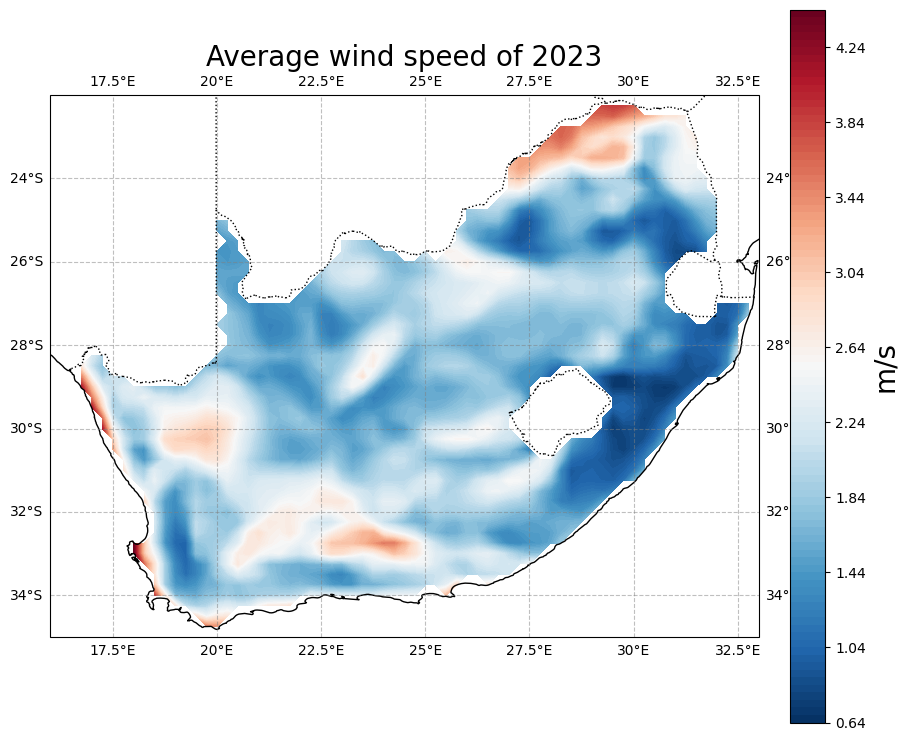

In [11]:
import numpy as np
import matplotlib.pyplot as plt
# Removed Basemap imports and usage, will use Cartopy instead
import netCDF4
import xarray as xr  # netCDF library
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader


shp_file2 = '/content/south_africa_Province_level_1.shp'

name2 = 'south africa' # Changed name2 to 'south africa' to match shape0 attribute value
shp_var2 = 'shape0' # Changed shp_var2 to 'shape0'

reader2  = shpreader.Reader(shp_file2)
country2 = [polygon for polygon in reader2.records() if polygon.attributes[shp_var2] == name2][0]

    # Generate the mask array and assign the result to the variable
masked_data2 = shp_mask_var(ds1, shp_file2, name2, shp_var2)
#


fig = plt.figure(figsize=(10,15))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Set extent for South Africa
ax.set_extent([16, 33, -35, -22], crs=ccrs.PlateCarree()) # [lon_min, lon_max, lat_min, lat_max]

# Plot the masked data
cs = ax.contourf(masked_data2.longitude, masked_data2.latitude, np.squeeze(masked_data2),
                 levels = 100, cmap='RdBu_r', transform=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Add gridlines and labels
grid_lines = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
grid_lines.xlabels_top = False
grid_lines.ylabels_right = False

plt.ylabel("Latitude", fontsize=20, labelpad=35)
plt.xlabel("Longitude", fontsize=20, labelpad=20) # This might be redundant with gridlines labels

#cbar = plt.colorbar(cs, ax=ax, orientation='vertical', pad=0.05, aspect=20)
#cbar.set_label('W/m2', fontsize=18)
cbar = plt.colorbar(cs, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('m/s', fontsize=20)

plt.title('Average wind speed of 2023', fontsize=20)
plt.show()

## Start the data fitting process into the Weibull distribution with Maximum likelihood estimator to calculate the values of K and C  

In [12]:
from scipy.stats import gamma
from scipy.optimize import fsolve

def fit_weibull_mle(ws_ts):
    """
    Fit Weibull parameters (k, c) to a 1D time series using MLE.
    """
    ws_ts = ws_ts[~np.isnan(ws_ts)] # remove missing data
    if len(ws_ts) == 0:
        return np.nan, np.nan

    # Initial guess for k using the approximation from the method of moments
    mean_wind = np.mean(ws_ts)
    std_wind = np.std(ws_ts)
    if std_wind == 0:
        return np.nan, np.nan
    k_guess = (std_wind / mean_wind) ** -1.086

    # Define the MLE equation to solve for k
    def equation_k(k):
        sum_ws_k = np.sum(ws_ts**k * np.log(ws_ts))
        sum_ws = np.sum(ws_ts**k)
        n = len(ws_ts)
        return (1/k) + np.sum(np.log(ws_ts))/n - sum_ws_k/sum_ws

    # Solve for k
    try:
        k = fsolve(equation_k, k_guess, full_output=False)[0]
        if k <= 0:
            return np.nan, np.nan
        # Calculate c from the found k
        c = (np.sum(ws_ts**k) / len(ws_ts)) ** (1/k)
        return k, c
    except:
        return np.nan, np.nan

# Apply the function along the time dimension
weibull_params = xr.apply_ufunc(
    fit_weibull_mle,
    wind_speed,
    input_core_dims=[['valid_time']], # Changed 'time' to 'valid_time'
    output_core_dims=[[], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float, float]
)

# Rename the outputs for clarity
weibull_k, weibull_c = weibull_params
weibull_k = weibull_k.rename('k')
weibull_c = weibull_c.rename('c')

# Calculate the power density from weibull parameters

In [13]:
from scipy.special import gamma, factorial


rho = 1.225  # kg/m³, standard air density

def wind_power_density(c, k, rho=1.225):
    """Calculate wind power density (W/m²) from Weibull parameters."""
    # Avoid division by zero or invalid values
    if k <= 0 or c <= 0:
        return np.nan
    # WPD = 0.5 * rho * c^3 * Gamma(1 + 3/k)
    return 0.5 * rho * c**3 * gamma(1 + 3/k)

# Apply the function point-wise
ds1 = xr.apply_ufunc(
    wind_power_density,
    weibull_c, weibull_k,
    vectorize=True,
    dask='parallelized'
)

ds1 = ds1.rename('wind_power_density')
# Convert to W/m², data is typically in the range of 0-2000 W/m²
ds1.attrs['units'] = 'W/m²'

ds1

<xarray.DataArray 'wind_power_density' (latitude: 53, longitude: 69)> Size: 29kB
array([[ 14.83587486,  16.65893195,  17.90650615, ...,  12.36433574,
         11.2611601 ,  10.43238095],
       [ 11.22665711,  10.4104089 ,   8.71860523, ...,  11.25616945,
          9.99469169,   9.23654952],
       [  8.41630467,   6.31725668,   5.26346822, ...,  11.399239  ,
          9.83378972,   8.99896713],
       ...,
       [187.36845691, 188.02918301, 187.63651587, ...,  28.99823168,
         28.84996399,  28.89009015],
       [168.88460746, 170.28874471, 168.60681566, ...,  30.26863417,
         30.163465  ,  30.26642433],
       [153.62471969, 152.82718664, 151.28245881, ...,  32.14970049,
         32.18857373,  31.84633313]])
Coordinates:
  * latitude   (latitude) float64 424B -22.0 -22.25 -22.5 ... -34.5 -34.75 -35.0
  * longitude  (longitude) float64 552B 16.0 16.25 16.5 ... 32.5 32.75 33.0
    number     int64 8B 0
Attributes: (12/27)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3657
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    units:                                    W/m²
    standard_name:                            unknown
    GRIB_surface:                             0.0

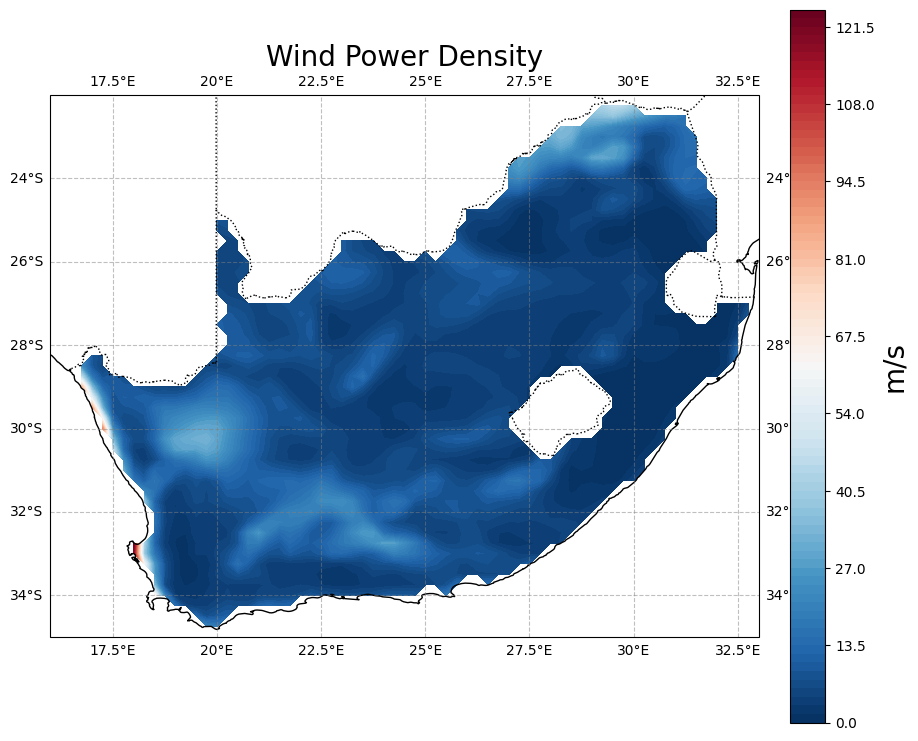

In [14]:
shp_file2 = '/content/south_africa_Province_level_1.shp'

name2 = 'south africa'
shp_var2 = 'shape0'

reader2  = shpreader.Reader(shp_file2)
country2 = [polygon for polygon in reader2.records() if polygon.attributes[shp_var2] == name2][0]

    # Generate the mask array and assign the result to the variable
masked_data2 = shp_mask_var(ds1, shp_file2, name2, shp_var2)


fig = plt.figure(figsize=(10,15))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Set extent for South Africa
ax.set_extent([16, 33, -35, -22], crs=ccrs.PlateCarree()) # [lon_min, lon_max, lat_min, lat_max]

# Plot the masked data
cs = ax.contourf(masked_data2.longitude, masked_data2.latitude, np.squeeze(masked_data2),
                 levels = 100, cmap='RdBu_r', transform=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Add gridlines and labels
grid_lines = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
grid_lines.xlabels_top = False
grid_lines.ylabels_right = False

plt.ylabel("Latitude", fontsize=20, labelpad=35)
plt.xlabel("Longitude", fontsize=20, labelpad=20) # This might be redundant with gridlines labels

#cbar = plt.colorbar(cs, ax=ax, orientation='vertical', pad=0.05, aspect=20)
#cbar.set_label('W/m2', fontsize=18)
cbar = plt.colorbar(cs, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('m/s', fontsize=20)

plt.title('Wind Power Density', fontsize=20)
plt.show()

# Plot power density using Basemap

# Calculate most probable wind speed using Weibull parameters

In [15]:
def most_probable_wind(c, k):
    """Calculate most probable wind speed from Weibull parameters."""
    # Avoid division by zero or invalid values
    if k <= 0 or c <= 0:
        return np.nan
    if k>1:
        return c*((k-1)/k)**(1/k)
    else:
            return 0.0

# Apply the function point-wise
ds1 = xr.apply_ufunc(
    most_probable_wind,
    weibull_c, weibull_k,
    vectorize=True,
    dask='parallelized'
)

ds1 = ds1.rename('Most probable wind')
# Convert to W/m², data is typically in the range of 0-2000 W/m²
ds1.attrs['units'] = 'm/s'

ds1

<xarray.DataArray 'Most probable wind' (latitude: 53, longitude: 69)> Size: 29kB
array([[1.73089854, 1.70498816, 1.60298267, ..., 2.50331787, 2.44312043,
        2.39013363],
       [1.61746973, 1.48797738, 1.21455385, ..., 2.40945589, 2.33700111,
        2.2942658 ],
       [1.40747216, 1.24944793, 1.1878872 , ..., 2.38936373, 2.30185668,
        2.25458064],
       ...,
       [6.00278039, 5.94481278, 5.86905412, ..., 2.34645428, 2.36002067,
        2.3790359 ],
       [5.89596084, 5.85302558, 5.76876909, ..., 2.30143959, 2.30983031,
        2.3280805 ],
       [5.79023096, 5.73216115, 5.65888873, ..., 2.24902428, 2.2653753 ,
        2.28297754]])
Coordinates:
  * latitude   (latitude) float64 424B -22.0 -22.25 -22.5 ... -34.5 -34.75 -35.0
  * longitude  (longitude) float64 552B 16.0 16.25 16.5 ... 32.5 32.75 33.0
    number     int64 8B 0
Attributes: (12/27)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3657
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    units:                                    m/s
    standard_name:                            unknown
    GRIB_surface:                             0.0

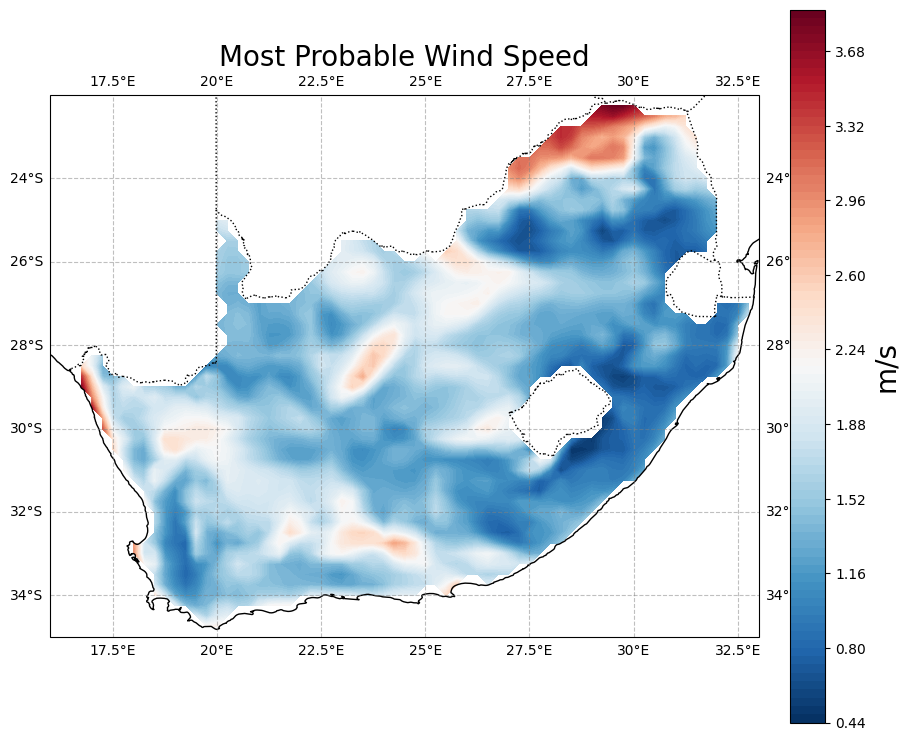

In [16]:
shp_file2 = '/content/south_africa_Province_level_1.shp'

name2 = 'south africa'
shp_var2 = 'shape0'

reader2  = shpreader.Reader(shp_file2)
country2 = [polygon for polygon in reader2.records() if polygon.attributes[shp_var2] == name2][0]

    # Generate the mask array and assign the result to the variable
masked_data2 = shp_mask_var(ds1, shp_file2, name2, shp_var2)


fig = plt.figure(figsize=(10,15))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Set extent for South Africa
ax.set_extent([16, 33, -35, -22], crs=ccrs.PlateCarree()) # [lon_min, lon_max, lat_min, lat_max]

# Plot the masked data
cs = ax.contourf(masked_data2.longitude, masked_data2.latitude, np.squeeze(masked_data2),
                 levels = 100, cmap='RdBu_r', transform=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Add gridlines and labels
grid_lines = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
grid_lines.xlabels_top = False
grid_lines.ylabels_right = False

plt.ylabel("Latitude", fontsize=20, labelpad=35)
plt.xlabel("Longitude", fontsize=20, labelpad=20) # This might be redundant with gridlines labels

##cbar = plt.colorbar(cs, ax=ax, orientation='vertical', pad=0.05, aspect=20)
#cbar.set_label('m/s', fontsize=20)
cbar = plt.colorbar(cs, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('m/s', fontsize=20)

plt.title('Most Probable Wind Speed', fontsize=20)
plt.show()

## Calculate and plot the wind speed carrying maximum energy from Weibull parameters.

In [17]:
def max_energy_wind(c, k):
    """Calculate the wind speed carrying maximum energy from Weibull parameters."""
    # Avoid division by zero or invalid values
    if k <= 0 or c <= 0:
        return np.nan
    if k>1:
        return c*((k+2)/k)**(1/k)
    else:
            return 0.0

# Apply the function point-wise
ds1 = xr.apply_ufunc(
    max_energy_wind,
    weibull_c, weibull_k,
    vectorize=True,
    dask='parallelized'
)

ds1 = ds1.rename('Maximum energy wind')
# Convert to W/m², data is typically in the range of 0-2000 W/m²
ds1.attrs['units'] = 'm/s'

ds1

<xarray.DataArray 'Maximum energy wind' (latitude: 53, longitude: 69)> Size: 29kB
array([[3.77441247, 3.96158997, 4.11732865, ..., 3.16234373, 3.05585946,
        2.97403366],
       [3.42309628, 3.37454055, 3.25851653, ..., 3.07425312, 2.94295744,
        2.85623391],
       [3.13491844, 2.86116101, 2.68731207, ..., 3.10368098, 2.93972142,
        2.84297291],
       ...,
       [7.92945484, 7.97213014, 8.00247908, ..., 4.6447296 , 4.62960619,
        4.62440921],
       [7.60798806, 7.66066028, 7.66915607, ..., 4.74379858, 4.73378061,
        4.73277672],
       [7.32880247, 7.34280917, 7.34719783, ..., 4.88058529, 4.87624265,
        4.84841989]])
Coordinates:
  * latitude   (latitude) float64 424B -22.0 -22.25 -22.5 ... -34.5 -34.75 -35.0
  * longitude  (longitude) float64 552B 16.0 16.25 16.5 ... 32.5 32.75 33.0
    number     int64 8B 0
Attributes: (12/27)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3657
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    units:                                    m/s
    standard_name:                            unknown
    GRIB_surface:                             0.0

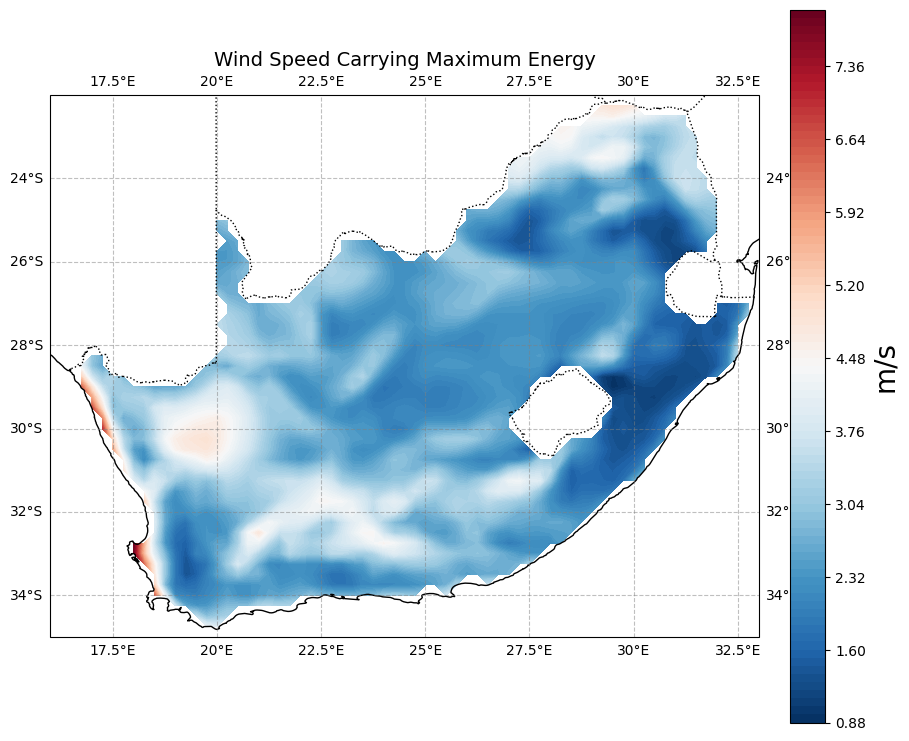

In [18]:
shp_file2 = '/content/south_africa_Province_level_1.shp'

name2 = 'south africa'
shp_var2 = 'shape0'

reader2  = shpreader.Reader(shp_file2)
country2 = [polygon for polygon in reader2.records() if polygon.attributes[shp_var2] == name2][0]

    # Generate the mask array and assign the result to the variable
masked_data2 = shp_mask_var(ds1, shp_file2, name2, shp_var2)


fig = plt.figure(figsize=(10,15))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Set extent for South Africa
ax.set_extent([16, 33, -35, -22], crs=ccrs.PlateCarree()) # [lon_min, lon_max, lat_min, lat_max]

# Plot the masked data
cs = ax.contourf(masked_data2.longitude, masked_data2.latitude, np.squeeze(masked_data2),
                 levels = 100, cmap='RdBu_r', transform=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Add gridlines and labels
grid_lines = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
grid_lines.xlabels_top = False
grid_lines.ylabels_right = False

plt.ylabel("Latitude", fontsize=20, labelpad=35)
plt.xlabel("Longitude", fontsize=20, labelpad=20) # This might be redundant with gridlines labels

cbar = plt.colorbar(cs, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('m/s', fontsize=20)

plt.title('Wind Speed Carrying Maximum Energy', fontsize=14)
plt.savefig('wind_speed_max_energy.png', dpi=300)
plt.show()

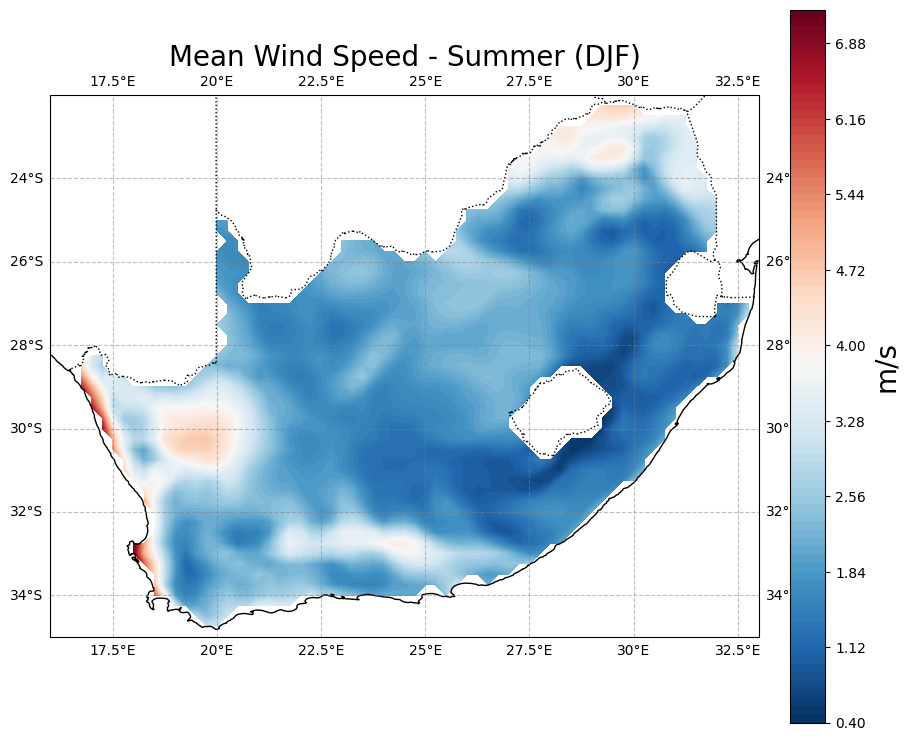

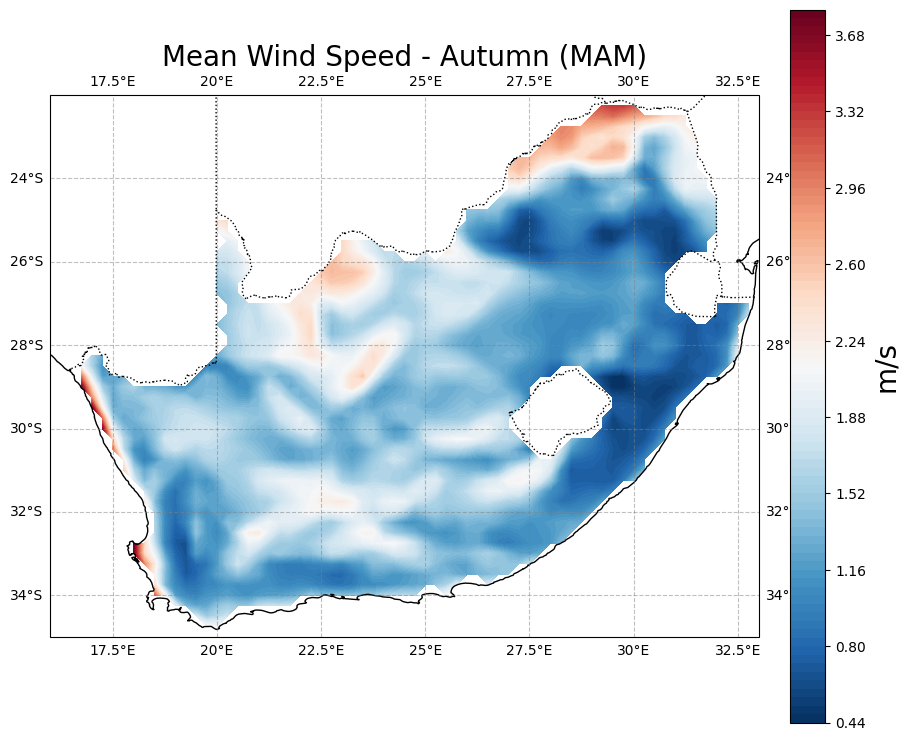

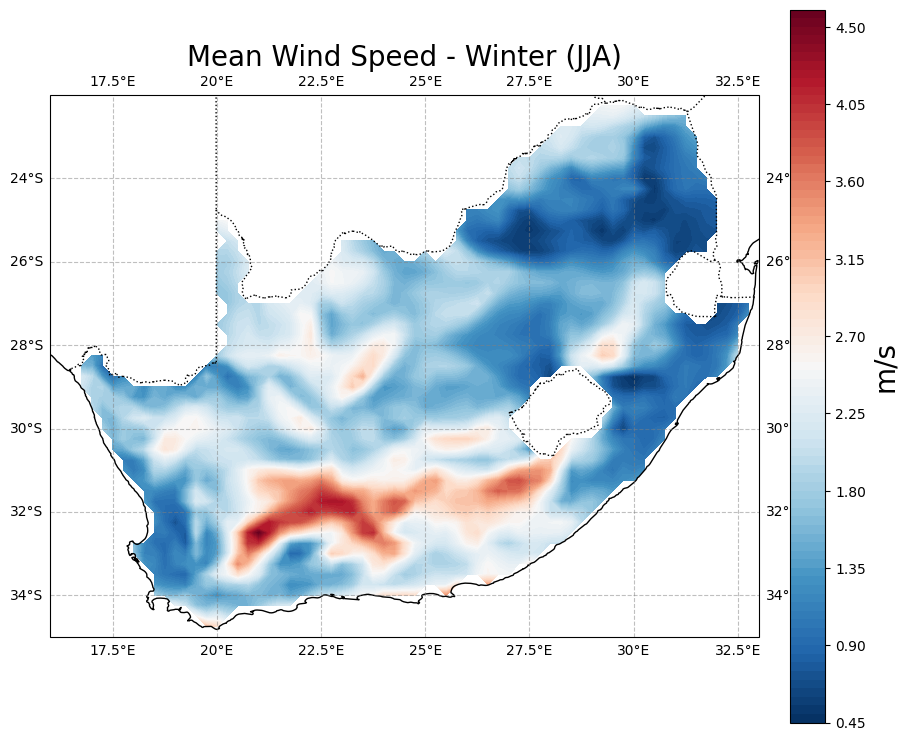

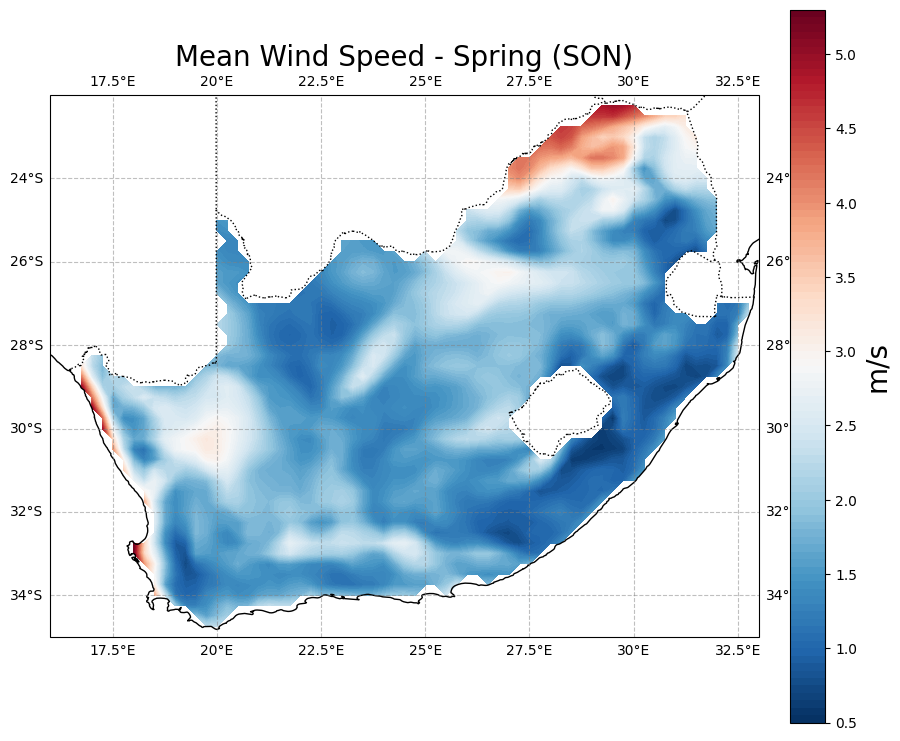

Generated seasonal mean wind speed maps.


In [20]:
# PART A: 4 Seasonal Mean Wind Speed Maps
# SA seasons: Summer=DJF(12,1,2), Autumn=MAM(3,4,5),
#             Winter=JJA(6,7,8),  Spring=SON(9,10,11)
seasons_months = {
    'Summer (DJF)': [12, 1, 2],
    'Autumn (MAM)': [3, 4, 5],
    'Winter (JJA)': [6, 7, 8],
    'Spring (SON)': [9, 10, 11]
}

# Assuming shp_file2, name2, shp_var2 are already defined from previous cells
# and wind_speed and shp_mask_var function are in memory.

for season_name, months in seasons_months.items():
    # Select data for the current season's months
    seasonal_wind_speed = wind_speed.sel(valid_time=wind_speed['valid_time'].dt.month.isin(months))

    # Calculate the mean wind speed for the season
    mean_seasonal_wind = seasonal_wind_speed.mean(dim='valid_time', keep_attrs=True)

    # Mask the data using the South Africa shapefile
    masked_seasonal_data = shp_mask_var(mean_seasonal_wind, shp_file2, name2, shp_var2)

    # Plotting
    fig = plt.figure(figsize=(10, 15))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Set extent for South Africa
    ax.set_extent([16, 33, -35, -22], crs=ccrs.PlateCarree())

    # Plot the masked data
    cs = ax.contourf(masked_seasonal_data.longitude, masked_seasonal_data.latitude, np.squeeze(masked_seasonal_data),
                     levels=100, cmap='RdBu_r', transform=ccrs.PlateCarree())

    # Add features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Add gridlines and labels
    grid_lines = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
    grid_lines.xlabels_top = False
    grid_lines.ylabels_right = False

    plt.ylabel("Latitude", fontsize=20, labelpad=35)
    plt.xlabel("Longitude", fontsize=20, labelpad=20)

    cbar = plt.colorbar(cs, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label('m/s', fontsize=20)

    plt.title(f'Mean Wind Speed - {season_name}', fontsize=20)

    # Save the plot as a high-resolution PNG
    plt.savefig(f'mean_wind_speed_{season_name.replace(" ", "_").replace("(", "").replace(")", "")}.png', dpi=300)
    plt.show()

print("Generated seasonal mean wind speed maps.")

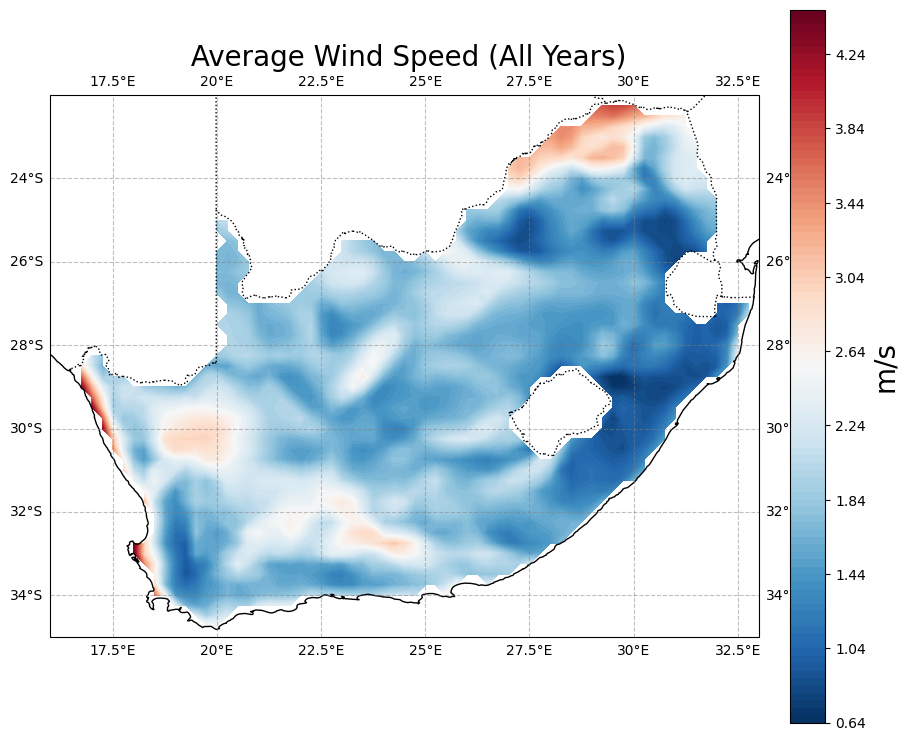

Generated long-term average wind speed map.


In [21]:
# Calculate the long-term mean wind speed across all years
mean_climatology_wind = wind_speed.mean(dim='valid_time', keep_attrs=True)

# Mask the data using the South Africa shapefile
masked_climatology_data = shp_mask_var(mean_climatology_wind, shp_file2, name2, shp_var2)

# Plotting
fig = plt.figure(figsize=(10, 15))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Set extent for South Africa
ax.set_extent([16, 33, -35, -22], crs=ccrs.PlateCarree())

# Plot the masked data
cs = ax.contourf(masked_climatology_data.longitude, masked_climatology_data.latitude, np.squeeze(masked_climatology_data),
                 levels=100, cmap='RdBu_r', transform=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Add gridlines and labels
grid_lines = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
grid_lines.xlabels_top = False
grid_lines.ylabels_right = False

plt.ylabel("Latitude", fontsize=20, labelpad=35)
plt.xlabel("Longitude", fontsize=20, labelpad=20)

cbar = plt.colorbar(cs, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('m/s', fontsize=20)

plt.title(' Average Wind Speed (All Years)', fontsize=20)

# Save the plot as a high-resolution PNG
plt.savefig('Average_wind_speed.png', dpi=300)
plt.show()

print("Generated long-term average wind speed map.")

### Combined 2x4 Wind Resource Assessment Grid
This cell aggregates the 8 key visualizations into a single high-resolution grid for a complete overview.

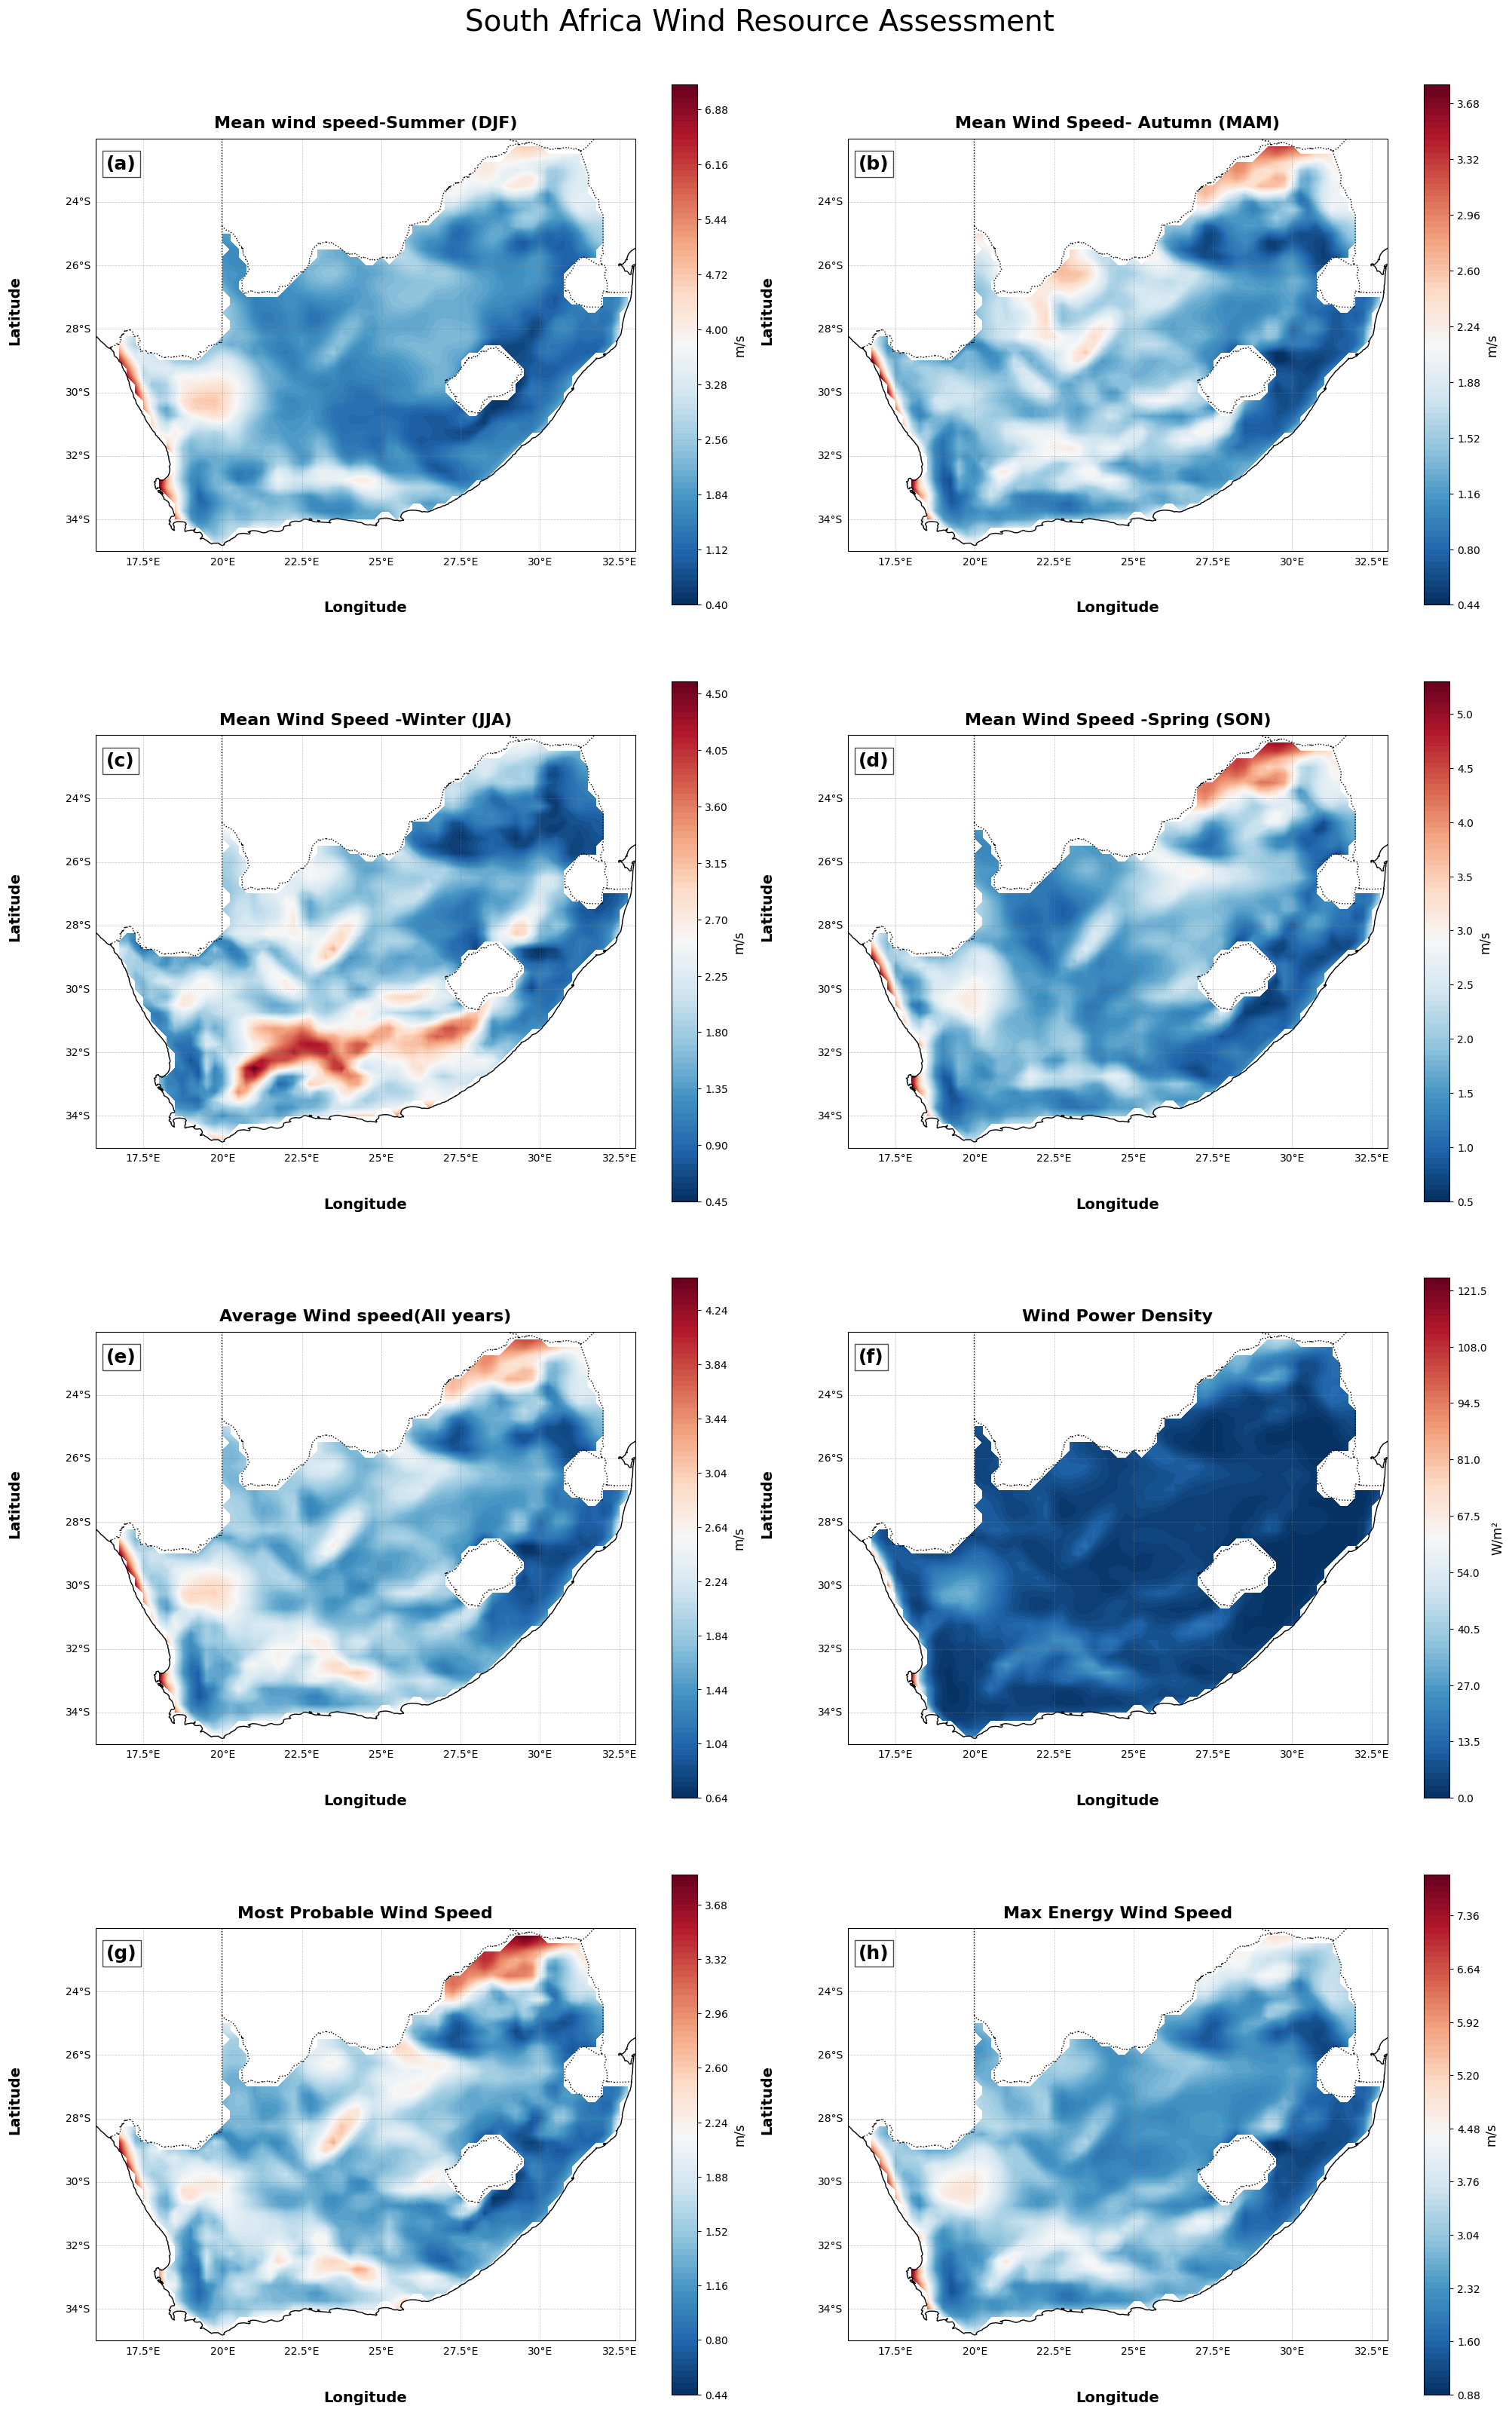

Initiating download for final_4x2_RdBu_grid.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from google.colab import files
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import string

# Helper function to get seasonal data for the grid
def get_masked_seasonal(months):
    s_ws = wind_speed.sel(valid_time=wind_speed['valid_time'].dt.month.isin(months)).mean(dim='valid_time')
    return shp_mask_var(s_ws, shp_file2, name2, shp_var2)

# Define the 8 datasets for our 4x2 layout
grid_items = [
    (get_masked_seasonal([12, 1, 2]), 'Mean wind speed-Summer (DJF)', 'm/s'),
    (get_masked_seasonal([3, 4, 5]), 'Mean Wind Speed- Autumn (MAM)', 'm/s'),
    (get_masked_seasonal([6, 7, 8]), 'Mean Wind Speed -Winter (JJA)', 'm/s'),
    (get_masked_seasonal([9, 10, 11]), 'Mean Wind Speed -Spring (SON)', 'm/s'),
    (masked_climatology_data, 'Average Wind speed(All years)', 'm/s'),
    (masked_wpd, 'Wind Power Density', 'W/m²'),
    (masked_mpws, 'Most Probable Wind Speed', 'm/s'),
    (masked_mews, 'Max Energy Wind Speed', 'm/s')
]

# Set up 4 rows and 2 columns
fig, axes = plt.subplots(4, 2, figsize=(20, 32), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (data, title, unit) in enumerate(grid_items):
    ax = axes[i]
    ax.set_extent([16, 33, -35, -22], crs=ccrs.PlateCarree())

    # Plot data with RdBu_r colormap and high level count for smoothness
    cs = ax.contourf(data.longitude, data.latitude, np.squeeze(data),
                    levels=100, cmap='RdBu_r', transform=ccrs.PlateCarree())

    # Add geographic details
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Subplot label (a, b, c...)
    ax.text(0.02, 0.96, f'({string.ascii_lowercase[i]})', transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='top', bbox=dict(facecolor='white', alpha=0.7))

    # Title
    ax.set_title(title, fontsize=16, fontweight='bold', pad=10)

    # Gridlines with Degree formatting
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    gl.bottom_labels = True
    gl.left_labels = True

    # BOLD Axis labels positioned near the map
    ax.text(0.5, -0.12, 'Longitude', va='top', ha='center', transform=ax.transAxes, fontsize=14, fontweight='bold')
    ax.text(-0.15, 0.5, 'Latitude', va='bottom', ha='center', rotation='vertical', transform=ax.transAxes, fontsize=14, fontweight='bold')

    # Individual colorbar per subplot
    cbar = fig.colorbar(cs, ax=ax, orientation='vertical', fraction=0.046, pad=0.06)
    cbar.set_label(unit, fontsize=12)

plt.suptitle('South Africa Wind Resource Assessment', fontsize=28, y=1.01)
plt.tight_layout(h_pad=3.5, w_pad=2.5)

# Save result
final_grid_path = 'final_4x2_RdBu_grid.png'
plt.savefig(final_grid_path, dpi=300, bbox_inches='tight')
plt.show()

# Trigger download
print(f"Initiating download for {final_grid_path}...")
files.download(final_grid_path)